In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Получение датафрейма

In [2]:
df = pd.read_csv("../Data/1_lab.csv")

In [3]:
df.head()

,x,y
0,-871,822
1,-532,288
2,466,-610
3,150,93
4,-600,-405


In [35]:
df.describe()

,x,y
count,433787.000000,433787.000000
mean,0.514501,1.666237
std,576.609881,577.911522
min,-1000.000000,-1000.000000
25%,-498.000000,-499.000000
50%,0.000000,3.000000
75%,499.000000,502.000000
max,1000.000000,1000.000000


Отбор нужныйх точек

In [13]:
LEFT_HIGH = (-100, 100)
RIGHT_LOW = (100, -100)
KOEF = 1.5

In [14]:
df_left = df[(df['x'] >= LEFT_HIGH[0]) & (df['y'] <= LEFT_HIGH[1])]
df_result = df_left[(df_left['x'] <= RIGHT_LOW[0]) & (df_left['y'] >= RIGHT_LOW[1])]

In [22]:

df_remains = df[~df.index.isin(df_result.index)]

In [23]:
df_result.describe()

,x,y
count,4577.000000,4577.000000
mean,0.945816,0.155342
std,59.489316,58.270658
min,-100.000000,-100.000000
25%,-50.000000,-51.000000
50%,1.000000,1.000000
75%,53.000000,51.000000
max,100.000000,100.000000


In [24]:
df_remains.describe()

,x,y
count,429210.000000,429210.000000
mean,0.509902,1.682349
std,579.643608,580.953541
min,-1000.000000,-1000.000000
25%,-503.000000,-504.000000
50%,0.000000,3.000000
75%,504.000000,507.000000
max,1000.000000,1000.000000


Отображение результата

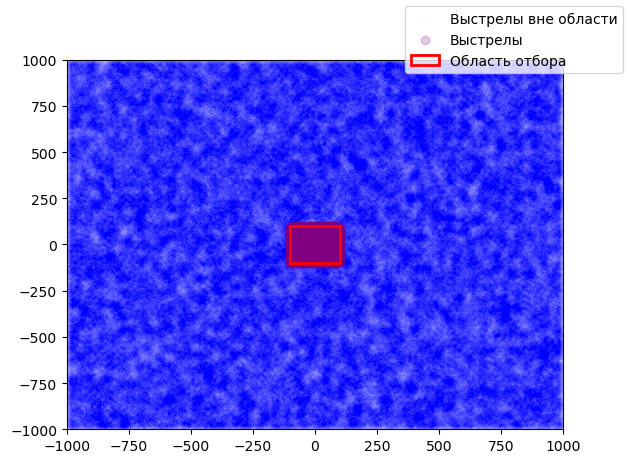

In [ ]:
fig, axis = plt.subplots()

axis.scatter(x=df_remains['x'], y=df_remains['y'], color='blue', alpha=0.005, label="Выстрелы вне области",)
axis.scatter(x=df_result['x'], y=df_result['y'], color='purple', alpha=0.2, label="Выстрелы")
axis.set_xlim(-1000, 1000)
axis.set_ylim(-1000, 1000)

rectange = patches.Rectangle(
    (LEFT_HIGH[0], RIGHT_LOW[1]),
    RIGHT_LOW[0] - LEFT_HIGH[0],
    LEFT_HIGH[1] - RIGHT_LOW[1],
    facecolor = "none",
    edgecolor = "red",
    lw = 2,
    label = "Область отбора"
)

axis.add_patch(rectange)
fig.legend()

In [32]:
df_sampled_result = df_result.sample(frac=0.05)
df_sampled_remains = df_remains.sample(frac=0.05)

Только часть данных

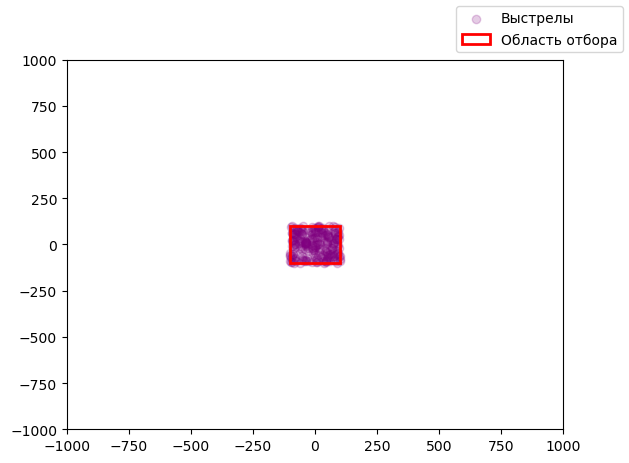

In [36]:
fig, axis = plt.subplots()

#axis.scatter(x=df_sampled_remains['x'], y=df_sampled_remains['y'], color='blue', alpha=0.07, label="Выстрелы вне области",)
axis.scatter(x=df_sampled_result['x'], y=df_sampled_result['y'], color='purple', alpha=0.2, label="Выстрелы")
axis.set_xlim(-1000, 1000)
axis.set_ylim(-1000, 1000)

rectange = patches.Rectangle(
    (LEFT_HIGH[0], RIGHT_LOW[1]),
    RIGHT_LOW[0] - LEFT_HIGH[0],
    LEFT_HIGH[1] - RIGHT_LOW[1],
    facecolor = "none",
    edgecolor = "red",
    lw = 2,
    label = "Область отбора"
)

axis.add_patch(rectange)
fig.legend()